In [174]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt


In [175]:
arquivo = 'dados_tratados.csv'

df = pd.read_csv(arquivo)
df

,ids,titles,abstracts,cs.AI,cs.CV,cs.DB,cs.LG,math.ST,physics.optics,quant-ph,stat.ML
0,2306.17702,Why Deep Models Often cannot Beat Non-deep Cou...,Molecular property prediction (MPP) is a cru...,0,0,0,1,0,0,0,0
1,2203.06430,Categories of Differentiable Polynomial Circui...,Reverse derivative categories (RDCs) have re...,0,0,0,1,0,0,0,0
2,2307.04400,ARK: Robust Knockoffs Inference with Coupling,We investigate the robustness of the model-X...,0,0,0,0,1,0,0,1
3,2310.16175,G-CASCADE: Efficient Cascaded Graph Convolutio...,"In recent years, medical image segmentation ...",0,1,0,1,0,0,0,0
4,1310.76720,Intrinsic Contextuality as the Crux of Conscio...,A stream of conscious experience is extremel...,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
11340,2201.00889,Biased Hypothesis Formation From Projection Pu...,The effect of bias on hypothesis formation i...,0,0,0,1,0,0,0,1
11341,1510.07298,Experimental system design for the integration...,We present a design for the experimental int...,0,0,0,0,0,0,1,0
11342,2207.04941,Wavelet Conditional Renormalization Group,We develop a multiscale approach to estimate...,0,0,0,1,0,0,0,0
11343,2012.12103,Fabrication of Ge2Sb2Te5 metasurfaces by direc...,We experimentally demonstrate fabrication of...,0,0,0,0,0,1,0,0


In [176]:
colunas = df.columns[3:]
colunas

Index(['cs.AI', 'cs.CV', 'cs.DB', 'cs.LG', 'math.ST', 'physics.optics',
       'quant-ph', 'stat.ML'],
      dtype='object')

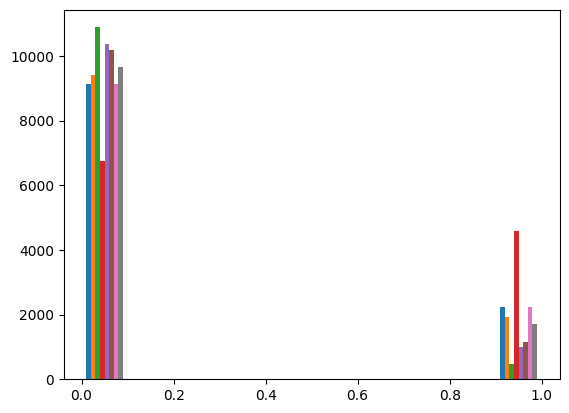

In [177]:
plt.hist(x = df[colunas])
plt.show()

In [178]:
contagem_categorias = df[colunas].sum()

# formatando result
contagem_df = contagem_categorias.reset_index()
contagem_df.columns = ['Categoria', 'Numero de Artigos']
contagem_df = contagem_df.sort_values(by='Numero de Artigos', ascending=False)

print(contagem_df)


        Categoria  Numero de Artigos
3           cs.LG               4584
6        quant-ph               2228
0           cs.AI               2224
1           cs.CV               1928
7         stat.ML               1701
5  physics.optics               1149
4         math.ST                989
2           cs.DB                460


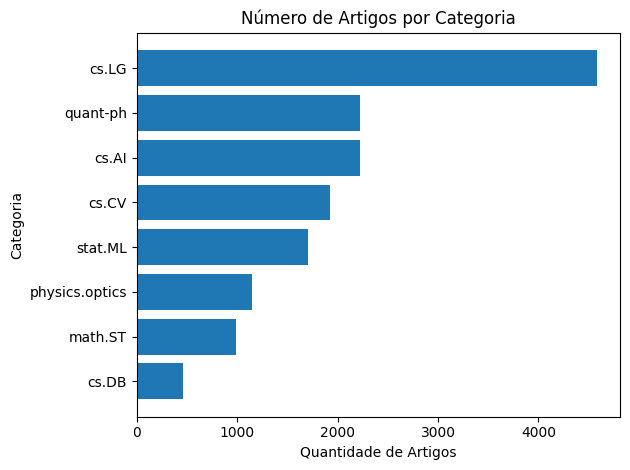

In [179]:
# graph de barras

# maior barra no topo, entao inverto o df
contagem_df_invertido = contagem_df.sort_values(by='Numero de Artigos', ascending=True)

# barras horizontais
plt.barh(y=contagem_df_invertido['Categoria'], width=contagem_df_invertido['Numero de Artigos'])

# titulos
plt.title('Número de Artigos por Categoria')
plt.xlabel('Quantidade de Artigos')
plt.ylabel('Categoria')

# ajustar layout
plt.tight_layout()

In [180]:
print(colunas)
colunas = list(colunas)

Index(['cs.AI', 'cs.CV', 'cs.DB', 'cs.LG', 'math.ST', 'physics.optics',
       'quant-ph', 'stat.ML'],
      dtype='object')


In [181]:
# Condição 1: A coluna 'cs.CV' deve ser 1
#condicao_principal = (df['cs.CV'] == 1)

# Condição 2: Nenhuma das outras colunas pode ser 1.
# Primeiro, somamos os valores 0/1 (True/False) nessas colunas para cada linha.
# Se a soma for 0, significa que todas são 0.
#condicao_exclusao = (df[colunasCV].sum(axis=1) == 0)

#artigosCV = df[condicao_principal & condicao_exclusao]

#artigosCV

lista_dados_unitarios = []
for i in colunas:
    condicao_principal = (df[i]==1)
    colunas_exclusao = colunas.copy()
    colunas_exclusao.remove(i)
    condicao_exclusao = (df[colunas_exclusao].sum(axis=1) == 0)
    artigos_unicos = df[condicao_principal & condicao_exclusao]
    lista_dados_unitarios.append(artigos_unicos)

print(lista_dados_unitarios[1])



              ids                                             titles  \
13     2007.15103  Cross-Modal Hierarchical Modelling for Fine-Gr...   
19     1909.06685  Automated Multiclass Cardiac Volume Segmentati...   
38     1906.04649  `Project & Excite' Modules for Segmentation of...   
40     1908.06422  Scene Classification in Indoor Environments fo...   
53     1008.05020  Fully automatic extraction of salient objects ...   
...           ...                                                ...   
11261  1909.01671  Distance transform regression for spatially-aw...   
11267  2201.05299  A Thousand Words Are Worth More Than a Picture...   
11300  1604.07741  EgoSampling: Wide View Hyperlapse from Egocent...   
11304  2302.00899  KST-Mixer: Kinematic Spatio-Temporal Data Mixe...   
11320  2210.05638       APSNet: Attention Based Point Cloud Sampling   

                                               abstracts  cs.AI  cs.CV  cs.DB  \
13       Sketch as an image search query is an ideal .

In [182]:
df_final = pd.concat(lista_dados_unitarios, ignore_index=True)
nome_do_arquivo = 'artigos_de_categoria_unica.csv'

df_final.to_csv(nome_do_arquivo, 
                index=False, # Não salva o índice do DataFrame como uma coluna
                encoding='utf-8') # Garante que caracteres especiais sejam salvos corretamente

print(f"Sucesso! Os dados mesclados foram salvos em: {nome_do_arquivo}")
print(f"Total de artigos únicos salvos: {len(df_final)}")



Sucesso! Os dados mesclados foram salvos em: artigos_de_categoria_unica.csv
Total de artigos únicos salvos: 8081


In [183]:
df_unitario = pd.read_csv('artigos_de_categoria_unica.csv')

Sucesso! O gráfico foi gerado e salvo como 'grafico_categorias_puras.png'.
As contagens (do maior para o menor) são:
cs.AI  cs.CV  cs.DB  cs.LG  math.ST  physics.optics  quant-ph  stat.ML
0      0      0      0      0        0               1         0          1964
                     1      0        0               0         0          1878
       1      0      0      0        0               0         0          1013
1      0      0      0      0        0               0         0           952
0      0      0      0      0        1               0         0           926
                            1        0               0         0           748
              1      0      0        0               0         0           348
              0      0      0        0               0         1           252
Name: count, dtype: int64


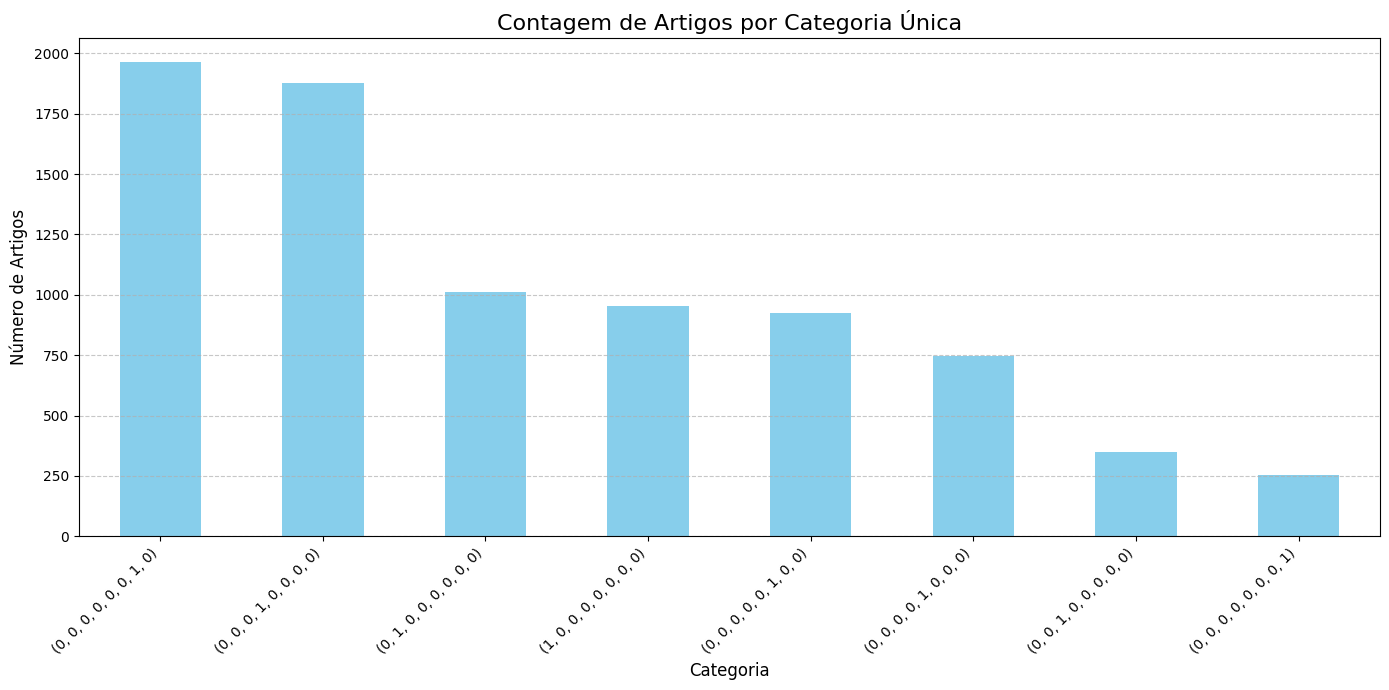

In [186]:
contagem_categorias = df_unitario[colunas].value_counts()

# 3. Criar o Gráfico de Barras

plt.figure(figsize=(14, 7))

# Gerar o gráfico usando a Série de contagens
contagem_categorias.plot(
    kind='bar',
    color='skyblue'
)

# Configurações do gráfico
plt.title('Contagem de Artigos por Categoria Única', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Número de Artigos', fontsize=12)

# Rotacionar os rótulos do eixo X para melhor legibilidade
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Salvar o gráfico em um arquivo PNG
plt.savefig('grafico_categorias_puras.png')

print("Sucesso! O gráfico foi gerado e salvo como 'grafico_categorias_puras.png'.")
print("As contagens (do maior para o menor) são:")
print(contagem_categorias)